In [1]:
%%lcm
list-saved-envs -e mypyenv

{
  "name": "mypyenv",
  "size": "2.5 GiB",
  "description": "Install Python seaborn and tensorflow packages",
  "tags": {
    "application": "OML4PY",
    "user": "OMLUSER"
  },
  "number_of_installed_packages": 158
}


In [2]:
%%lcm
download mypyenv --overwrite

Download successful for conda environment mypyenv


In [3]:
%%conda
activate mypyenv

Conda environment 'mypyenv' activated


In [4]:
%%conda
list

# packages in environment at /u01/.conda/envs/mypyenv:
#
# Name                    Version                   Build  Channel
_openmp_mutex             4.5                      20_gnu    conda-forge
_x86_64-microarch-level   3                        3_zen2    conda-forge
absl-py                   2.5.0              pyhd8ed1ab_0    conda-forge
astunparse                1.6.3              pyhd8ed1ab_3    conda-forge
aws-c-auth                0.10.4               hb7a77c6_1    conda-forge
aws-c-cal                 0.9.14               h2aa3ae6_4    conda-forge
aws-c-common              0.14.2               hb03c661_0    conda-forge
aws-c-compression         0.3.2                h720e601_4    conda-forge
aws-c-http                0.11.0               h38ae05a_4    conda-forge
aws-c-io                  0.27.3               h6f4d18d_1    conda-forge
aws-c-s3                  0.12.8               h46fcd08_1    conda-forge
aws-c-sdkutils            0.2.7                h720e601_2    conda-forge


In [5]:
import warnings
warnings.filterwarnings("ignore")

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

In [6]:
import pandas as pd

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

df = sns.load_dataset("iris")

display(df)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


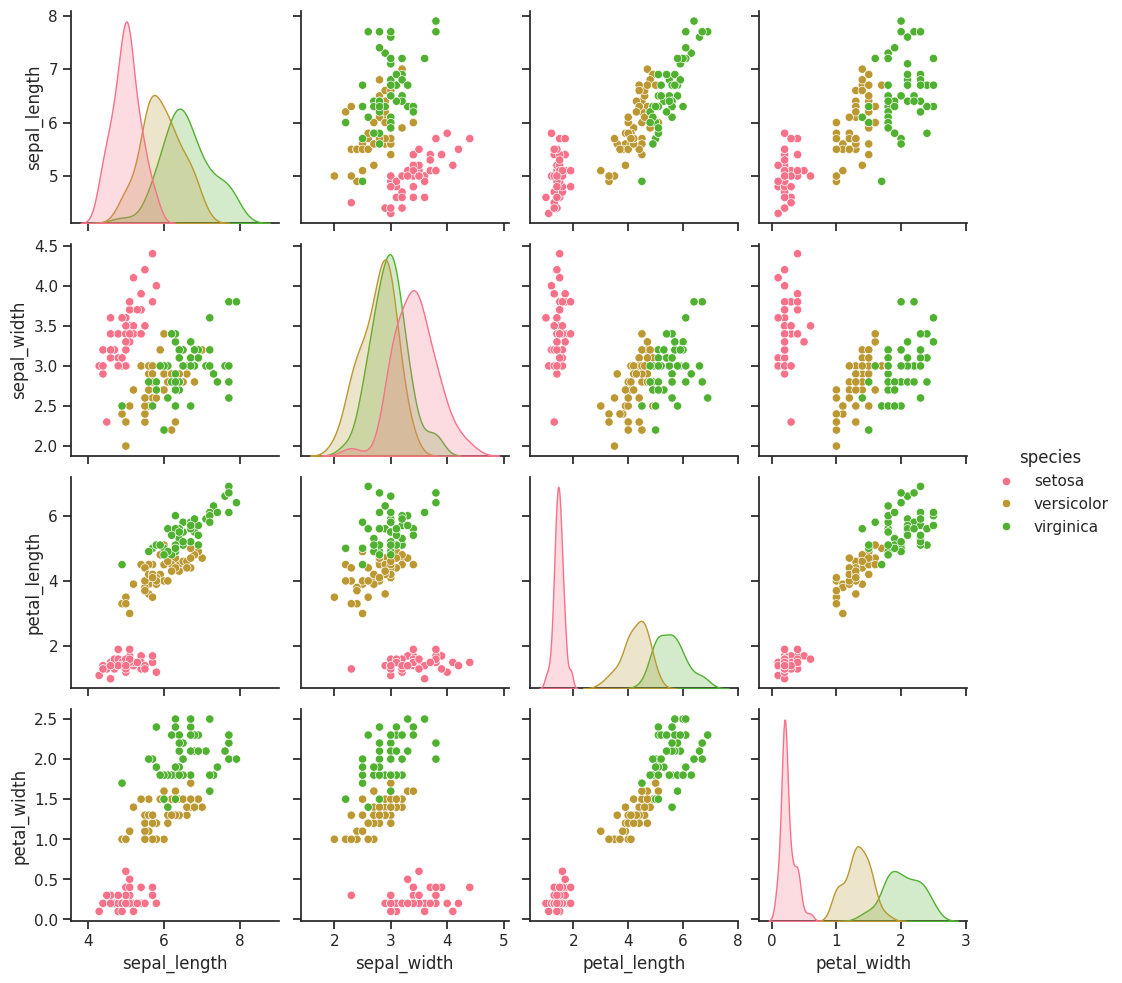

In [7]:
sns.set(style="ticks")
sns.set_palette("husl")
sns.pairplot(df.iloc[:,0:6], hue="species")

In [8]:
X = df.iloc[:,0:4].values
y = df.iloc[:,4].values

from sklearn.preprocessing import LabelEncoder
encoder =  LabelEncoder()
y1 = encoder.fit_transform(y)
Y = pd.get_dummies(y1).values

from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0) 

In [9]:
model = Sequential()

model.add(Dense(4,input_shape=(4,), activation='relu'))
model.add(Dense(3,activation='softmax'))

# compile the model using the atom optimizer with a learning rate of 0.04 and a loss function of 
# categorical cross-entropy and the parameter set to optimize is accuracy.
model.compile(Adam(learning_rate=0.04),'categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train,y_train, epochs=50)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3417 - loss: 1.1720  
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5750 - loss: 1.0378 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5583 - loss: 0.8794 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6083 - loss: 0.7636 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6917 - loss: 0.6431 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6917 - loss: 0.5626 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6917 - loss: 0.4829 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9000 - loss: 0.4394 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8917 - loss: 0.4032 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8000 - loss: 0.3653 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9583 - loss: 0.3230 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9583 - loss: 0.2867 


In [10]:
y_pred = model.predict(X_test, verbose=0)
y_pred

array([[7.80603013e-11, 7.46431469e-04, 9.99253511e-01],
       [2.54553946e-04, 9.97048318e-01, 2.69706571e-03],
       [9.99514222e-01, 4.85752302e-04, 3.06802957e-14],
       [2.33646880e-10, 1.56785212e-02, 9.84321475e-01],
       [9.98560905e-01, 1.43900246e-03, 2.89695221e-12],
       [1.85610490e-12, 1.46971244e-04, 9.99853015e-01],
       [9.98586535e-01, 1.41343626e-03, 2.68735728e-12],
       [5.23586095e-05, 9.88366604e-01, 1.15809850e-02],
       [1.77670136e-05, 9.78752732e-01, 2.12294608e-02],
       [6.42119150e-04, 9.97581482e-01, 1.77637755e-03],
       [3.48429658e-08, 7.82240257e-02, 9.21775937e-01],
       [1.68928542e-04, 9.92703855e-01, 7.12732272e-03],
       [6.49094945e-05, 9.78301942e-01, 2.16330141e-02],
       [2.58444179e-05, 9.62626100e-01, 3.73480506e-02],
       [3.93329065e-05, 9.42119658e-01, 5.78410588e-02],
       [9.98989224e-01, 1.01074611e-03, 6.59650557e-13],
       [5.65959672e-05, 9.39537287e-01, 6.04060963e-02],
       [1.03292041e-04, 9.44514

In [11]:
y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

report = classification_report(y_test_class,y_pred_class, output_dict=True)

res = pd.DataFrame(report)
res

,0,1,2,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0,1.0
support,11.0,13.0,6.0,1.0,30.0,30.0


In [12]:
def build_mod(df):
  import oml
  import keras
  from keras.models import Sequential
  from keras.layers import Dense
  from keras.optimizers import Adam
  import seaborn as sns
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt

  sns.set(style="ticks")
  sns.set_palette("husl")
  sns.pairplot(df.iloc[:,0:6], hue="species")

  # split the data into test and train sets
  X = df.iloc[:,0:4].values
  y = df.iloc[:,4].values

  from sklearn.preprocessing import LabelEncoder
  encoder =  LabelEncoder()
  y1 = encoder.fit_transform(y)
  Y = pd.get_dummies(y1).values

  from sklearn.model_selection import train_test_split
  X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,
    random_state=0) 

  model = Sequential()
  model.add(Dense(4,input_shape=(4,),activation='relu'))
  model.add(Dense(3,activation='softmax'))
  model.compile(Adam(learning_rate=0.04),'categorical_crossentropy',metrics=['accuracy'])
  model.fit(X_train,y_train, epochs=50, verbose=0)

  y_pred = model.predict(X_test, verbose=0)
  y_test_class = np.argmax(y_test,axis=1)
  y_pred_class = np.argmax(y_pred,axis=1)
  
  from sklearn.metrics import classification_report,confusion_matrix
  report = classification_report(y_test_class,y_pred_class, output_dict=True)
  res = pd.DataFrame(report)
  return print(res)
  plt.show()

              0          1         2  accuracy  macro avg  weighted avg
precision   1.0   1.000000  0.857143  0.966667   0.952381      0.971429
recall      1.0   0.923077  1.000000  0.966667   0.974359      0.966667
f1-score    1.0   0.960000  0.923077  0.966667   0.961026      0.967282
support    11.0  13.000000  6.000000  0.966667  30.000000     30.000000


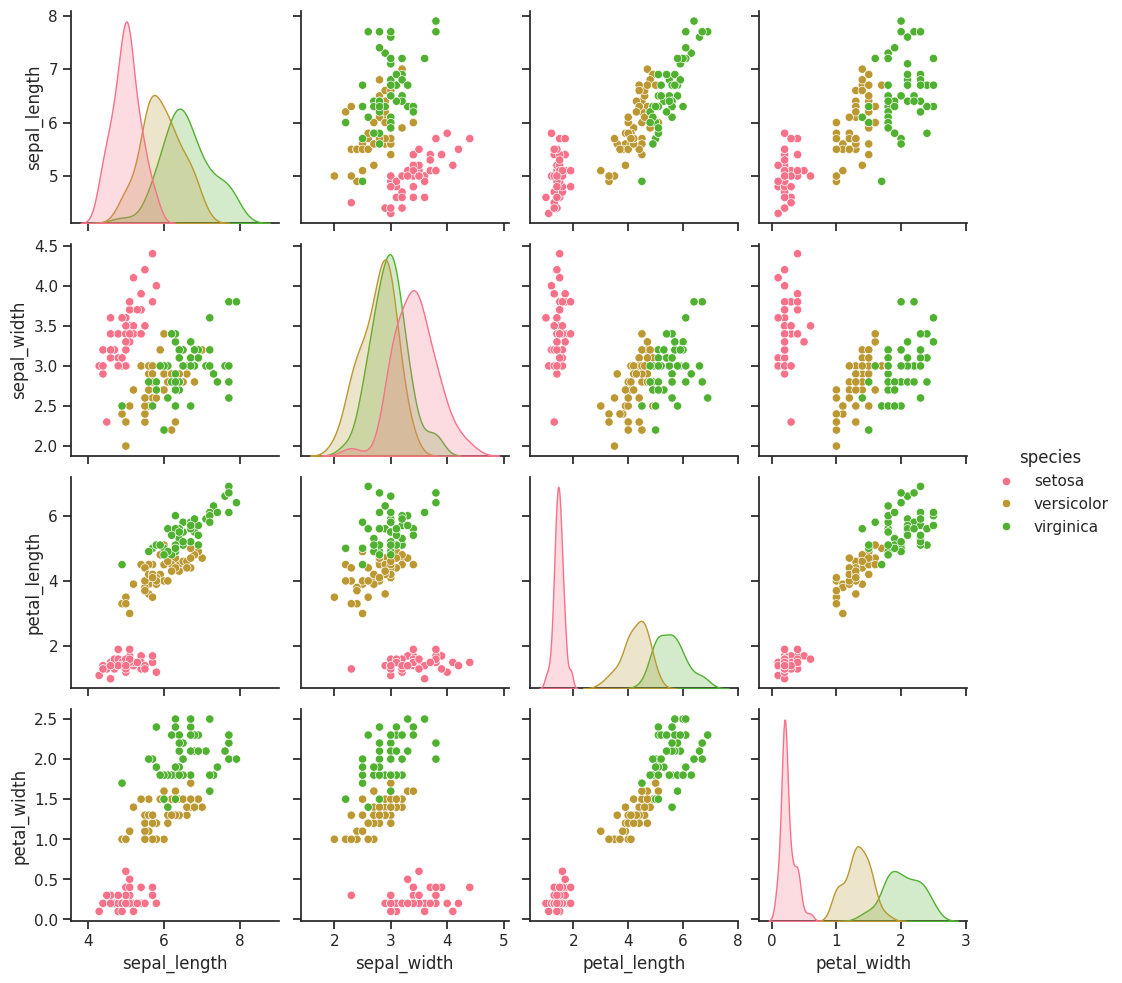

In [13]:
build_mod(df)

In [14]:
import oml

oml.connect(
    user="",
    password="",
    dsn="adwp_low",
    automl="adwp_low_drcp",
)

print("connected =", oml.isconnected())
print("EPE available =", oml.check_embed())

oml.do_eval(func="def epe_ping():\n    return 'EPE_OK'")

connected = True
EPE available = True


'EPE_OK'

In [15]:
import oml

try:
    oml.drop(table="DF")
except: 
    pass

MY_DF = oml.create(df, table="DF")
display(MY_DF)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]

              0     1    2  accuracy  macro avg  weighted avg
precision   1.0   1.0  1.0       1.0        1.0           1.0
recall      1.0   1.0  1.0       1.0        1.0           1.0
f1-score    1.0   1.0  1.0       1.0        1.0           1.0
support    11.0  13.0  6.0       1.0       30.0          30.0


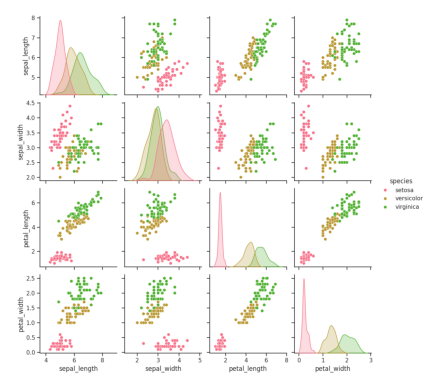

None

In [16]:
oml.table_apply(MY_DF, func=build_mod, graphics=True)

In [17]:
build_mod = """def build_mod(df):
  import oml
  import warnings
  warnings.filterwarnings("ignore")
  import keras
  from keras.models import Sequential
  from keras.layers import Dense
  from keras.optimizers import Adam
  import seaborn as sns
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  
  sns.set(style="ticks")
  sns.set_palette("husl")
  sns.pairplot(df.iloc[:,0:6], hue="species")

  # split the data into test and train sets
  X = df.iloc[:,0:4].values
  y = df.iloc[:,4].values

  from sklearn.preprocessing import LabelEncoder
  encoder =  LabelEncoder()
  y1 = encoder.fit_transform(y)
  Y = pd.get_dummies(y1).values

  from sklearn.model_selection import train_test_split
  X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0) 

  model = Sequential()
  model.add(Dense(4,input_shape=(4,),activation='relu'))
  model.add(Dense(3,activation='softmax'))
  model.compile(Adam(learning_rate=0.04),'categorical_crossentropy',metrics=['accuracy'])
  model.fit(X_train,y_train, epochs=50, verbose=0)

  y_pred = model.predict(X_test, verbose=0)
  y_test_class = np.argmax(y_test,axis=1)
  y_pred_class = np.argmax(y_pred,axis=1)

  from sklearn.metrics import classification_report,confusion_matrix
  report = classification_report(y_test_class,y_pred_class, output_dict=True)
  res = pd.DataFrame(report)
  return(res)
  plt.show()"""
  

In [18]:
oml.script.create("build_mod", func=build_mod, overwrite=True)

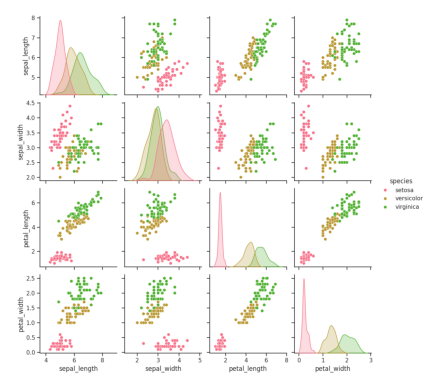

              0     1    2  accuracy  macro avg  weighted avg
precision   1.0   1.0  1.0       1.0        1.0           1.0
recall      1.0   1.0  1.0       1.0        1.0           1.0
f1-score    1.0   1.0  1.0       1.0        1.0           1.0
support    11.0  13.0  6.0       1.0       30.0          30.0

In [19]:
oml.table_apply(MY_DF, func="build_mod", graphics=True)